In [1]:
import pandas as pd


In [6]:
# Load dataset
from tkinter import filedialog
filedialog.askopenfilename()

'C:/Users/This pc/Downloads/SuperStore Sales DataSet - Sheet1.csv'

In [31]:
df = pd.read_csv('C:/Users/This pc/Downloads/SuperStore Sales DataSet - Sheet1.csv')

In [10]:
# Basic info
print(df.head())

   Row ID+O6G3A1:R6        Order ID Order Date Ship Date       Ship Mode  \
0              4918  CA-2019-160304   1/1/2019  1/7/2019  Standard Class   
1              4919  CA-2019-160304   1/2/2019  1/7/2019  Standard Class   
2              4920  CA-2019-160304   1/2/2019  1/7/2019  Standard Class   
3              3074  CA-2019-125206   1/3/2019  1/5/2019     First Class   
4              8604  US-2019-116365   1/3/2019  1/8/2019  Standard Class   

  Customer ID      Customer Name    Segment        Country          City  ...  \
0    BM-11575      Brendan Murry  Corporate  United States  Gaithersburg  ...   
1    BM-11575      Brendan Murry  Corporate  United States  Gaithersburg  ...   
2    BM-11575      Brendan Murry  Corporate  United States  Gaithersburg  ...   
3    LR-16915       Lena Radford   Consumer  United States   Los Angeles  ...   
4    CA-12310  Christine Abelman  Corporate  United States   San Antonio  ...   

          Category Sub-Category  \
0        Furniture   

In [11]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Row ID+O6G3A1:R6  5901 non-null   int64  
 1   Order ID          5901 non-null   object 
 2   Order Date        5901 non-null   object 
 3   Ship Date         5901 non-null   object 
 4   Ship Mode         5901 non-null   object 
 5   Customer ID       5901 non-null   object 
 6   Customer Name     5901 non-null   object 
 7   Segment           5901 non-null   object 
 8   Country           5901 non-null   object 
 9   City              5901 non-null   object 
 10  State             5901 non-null   object 
 11  Region            5901 non-null   object 
 12  Product ID        5901 non-null   object 
 13  Category          5901 non-null   object 
 14  Sub-Category      5901 non-null   object 
 15  Product Name      5901 non-null   object 
 16  Sales             5901 non-null   float64


In [12]:
# Clean data
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [13]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Row ID+O6G3A1:R6  0 non-null      int64  
 1   Order ID          0 non-null      object 
 2   Order Date        0 non-null      object 
 3   Ship Date         0 non-null      object 
 4   Ship Mode         0 non-null      object 
 5   Customer ID       0 non-null      object 
 6   Customer Name     0 non-null      object 
 7   Segment           0 non-null      object 
 8   Country           0 non-null      object 
 9   City              0 non-null      object 
 10  State             0 non-null      object 
 11  Region            0 non-null      object 
 12  Product ID        0 non-null      object 
 13  Category          0 non-null      object 
 14  Sub-Category      0 non-null      object 
 15  Product Name      0 non-null      object 
 16  Sales             0 non-null      float64
 17  Quantity      

In [20]:
# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [21]:
# Feature engineering
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [22]:
# Profit margin
df['Profit_Margin'] = df['Profit'] / df['Sales']

ANALYSIS

In [32]:

# 1. Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Office Supplies    643707.6870
Technology         470587.9910
Furniture          451508.6452
Name: Sales, dtype: float64


In [33]:
# 2. Profit by Region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(region_profit)

Region
West       67859.9582
East       53400.4243
Central    27450.0071
South      26551.7163
Name: Profit, dtype: float64


In [34]:
# 3. Top Customers
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer Name
Caroline Jumper    11596.974
Karen Ferguson     10941.274
Seth Vernon        10751.148
Helen Wasserman    10074.934
Edward Hooks        9542.988
Bill Shonely        9199.780
Pete Kriz           8812.054
John Lee            8765.332
Adam Bellavance     8167.080
Jane Waco           7933.554
Name: Sales, dtype: float64


In [35]:
# 4. Discount impact by Segment
discount_effect = df.groupby('Segment')['Profit'].mean()
print(discount_effect)

Segment
Consumer       27.140003
Corporate      32.585005
Home Office    31.962583
Name: Profit, dtype: float64


In [40]:
# Recreate columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

EDA ANALYSIS

<Axes: xlabel='Year,Month'>

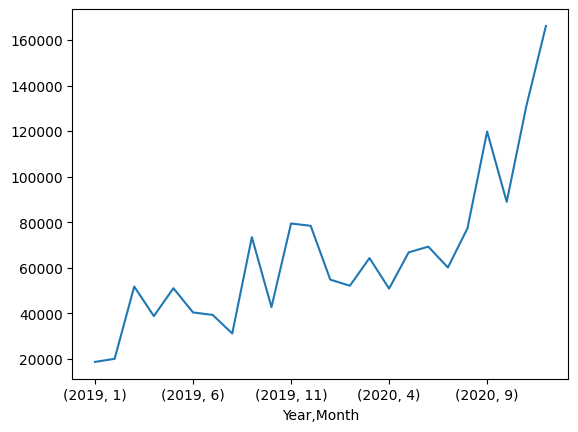

In [41]:
# Sales Trend Over Time 📈
df.groupby(['Year','Month'])['Sales'].sum().plot()

<Axes: xlabel='Category'>

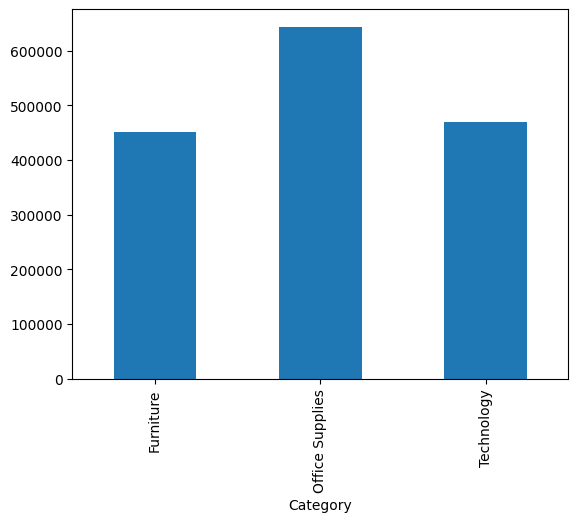

In [43]:
#Sales by Category 📊
df.groupby('Category')['Sales'].sum().plot(kind='bar')

In [54]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

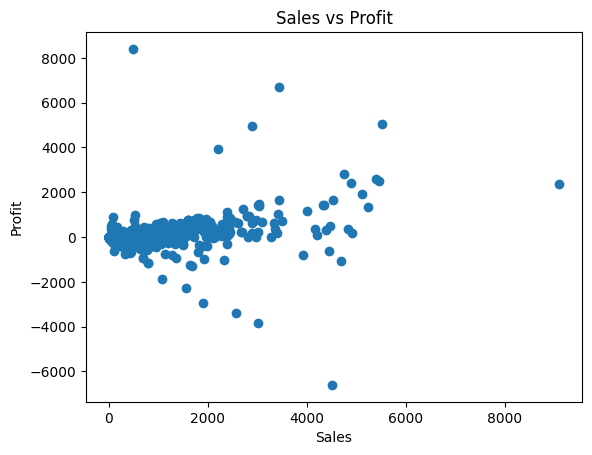

In [61]:
plt.scatter(df['sales'], df['profit'])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

In [ ]:
#Profit by Region 🌍
df.groupby('region')['profit'].sum().plot(kind='bar')

KeyError: 'Region'